In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay,
                             mean_squared_error, mean_absolute_error, r2_score)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

# Load clean data
df = pd.read_csv("players_clean.csv")
print("✅ Data loaded:", df.shape)
print(df.head())

✅ Data loaded: (129, 37)
   ranking_position  ranking_points  ranking_change  total_titles  \
0              25.0         15803.0             5.0             3   
1              86.0          4493.0             3.0            17   
2              16.0         17071.0            -2.0             8   
3              32.0         13869.0            -2.0             8   
4              95.0          3389.0            -2.0            14   

   titles_premier_padel  titles_world_padel_tour  total_finals  \
0                     1                        2             8   
1                     9                        8            20   
2                     3                        5            14   
3                     3                        5             8   
4                     5                        9            23   

   win_rate_finals  contract_value_eur  yearly_rackets  ...  \
0            37.50             22151.0            24.0  ...   
1            85.00            184049.

Target distribution:
is_top_player
0    88
1    41
Name: count, dtype: int64
Top players: 41 / 129

Train: 103 rows | Test: 26 rows

LR Best params: {'C': 0.1, 'solver': 'liblinear'}
RF Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}

══ CLASSIFICATION METRICS ══
           Logistic Regression  Random Forest
Accuracy                 0.769          0.808
Precision                0.625          0.714
Recall                   0.625          0.625
F1-Score                 0.625          0.667
ROC-AUC                  0.812          0.854


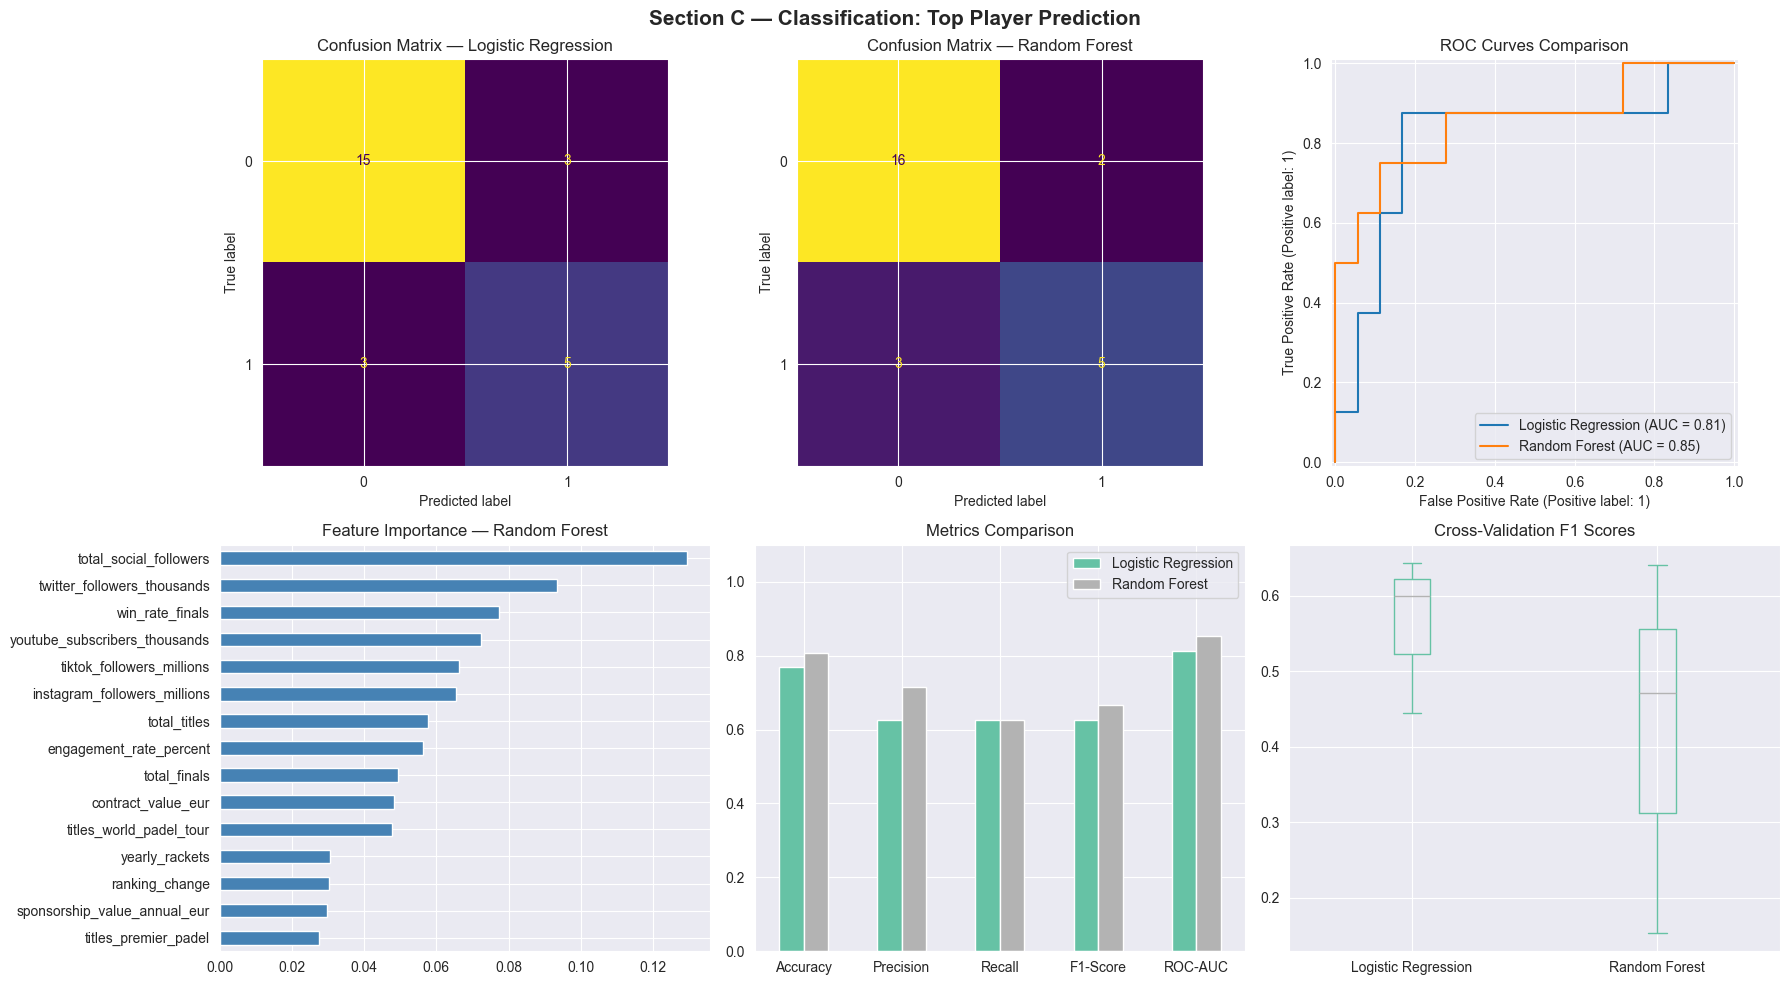


🏆 Best Classification Model: Random Forest


In [2]:
# ══════════════════════════════════════════════════════════
# SECTION C — CLASSIFICATION
# Predict: is_top_player (Top 20 player or not?)
# ══════════════════════════════════════════════════════════

# ── Prepare X and y ──
target = 'is_top_player'
drop_cols = [target, 'ranking_position', 'ranking_points', 'performance_score']

X = df.drop(columns=drop_cols)
y = df[target]

print("Target distribution:")
print(y.value_counts())
print(f"Top players: {y.sum()} / {len(y)}")


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

# ── Scale ──
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── Model 1: Logistic Regression + GridSearch ──
param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['lbfgs', 'liblinear']}
lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                  param_grid_lr, cv=3, scoring='f1')
lr.fit(X_train_sc, y_train)
best_lr = lr.best_estimator_
y_pred_lr = best_lr.predict(X_test_sc)
y_prob_lr = best_lr.predict_proba(X_test_sc)[:, 1]
print(f"\nLR Best params: {lr.best_params_}")

# ── Model 2: Random Forest + GridSearch ──
param_grid_rf = {'n_estimators': [50, 100, 200],
                 'max_depth': [3, 5, None],
                 'min_samples_split': [2, 5]}
rf = GridSearchCV(RandomForestClassifier(random_state=42),
                  param_grid_rf, cv=3, scoring='f1')
rf.fit(X_train, y_train)
best_rf = rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]
print(f"RF Best params: {rf.best_params_}")

# ── Metrics ──
metrics_c = pd.DataFrame({
    'Logistic Regression': [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_lr, zero_division=0),
        f1_score(y_test, y_pred_lr, zero_division=0),
        roc_auc_score(y_test, y_prob_lr)
    ],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0),
        roc_auc_score(y_test, y_prob_rf)
    ]
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])

print("\n══ CLASSIFICATION METRICS ══")
print(metrics_c.round(3))

# ── Visualizations ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Section C — Classification: Top Player Prediction", fontsize=15, fontweight='bold')

# Confusion Matrix LR
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr)).plot(ax=axes[0,0], colorbar=False)
axes[0,0].set_title("Confusion Matrix — Logistic Regression")

# Confusion Matrix RF
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf)).plot(ax=axes[0,1], colorbar=False)
axes[0,1].set_title("Confusion Matrix — Random Forest")

# ROC Curves
RocCurveDisplay.from_predictions(y_test, y_prob_lr, ax=axes[0,2], name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test, y_prob_rf, ax=axes[0,2], name="Random Forest")
axes[0,2].set_title("ROC Curves Comparison")

# Feature Importance
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).tail(15).plot(kind='barh', ax=axes[1,0], color='steelblue')
axes[1,0].set_title("Feature Importance — Random Forest")

# Metrics Comparison Bar
metrics_c.plot(kind='bar', ax=axes[1,1], rot=0, colormap='Set2')
axes[1,1].set_title("Metrics Comparison")
axes[1,1].set_ylim(0, 1.1)

# Cross Validation
cv_lr = cross_val_score(best_lr, X_train_sc, y_train, cv=3, scoring='f1')
cv_rf = cross_val_score(best_rf, X_train,    y_train, cv=3, scoring='f1')
pd.DataFrame({'Logistic Regression': cv_lr, 'Random Forest': cv_rf}).plot(
    kind='box', ax=axes[1,2], colormap='Set2')
axes[1,2].set_title("Cross-Validation F1 Scores")

plt.tight_layout()
plt.show()

best_model_c = "Random Forest" if metrics_c.loc['F1-Score','Random Forest'] >= metrics_c.loc['F1-Score','Logistic Regression'] else "Logistic Regression"
print(f"\n🏆 Best Classification Model: {best_model_c}")

Target stats:
count       129.000000
mean     193471.209302
std      187795.272623
min       16605.000000
25%       56949.000000
50%      139134.000000
75%      238638.000000
max      886821.000000
Name: contract_value_eur, dtype: float64

Ridge Best alpha: {'alpha': 100}
RF Regressor Best params: {'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 200}

── Ridge Regression ──
MSE  : 41,944,286,037.77
RMSE : 204,803.04
MAE  : 139,573.08
R²   : -0.087

── Random Forest Regressor ──
MSE  : 51,432,044,165.92
RMSE : 226,786.34
MAE  : 158,384.68
R²   : -0.333

══ REGRESSION METRICS ══
             Ridge  Random Forest
MSE   4.194429e+10   5.143204e+10
RMSE  2.048030e+05   2.267863e+05
MAE   1.395731e+05   1.583847e+05
R²   -8.700000e-02  -3.330000e-01


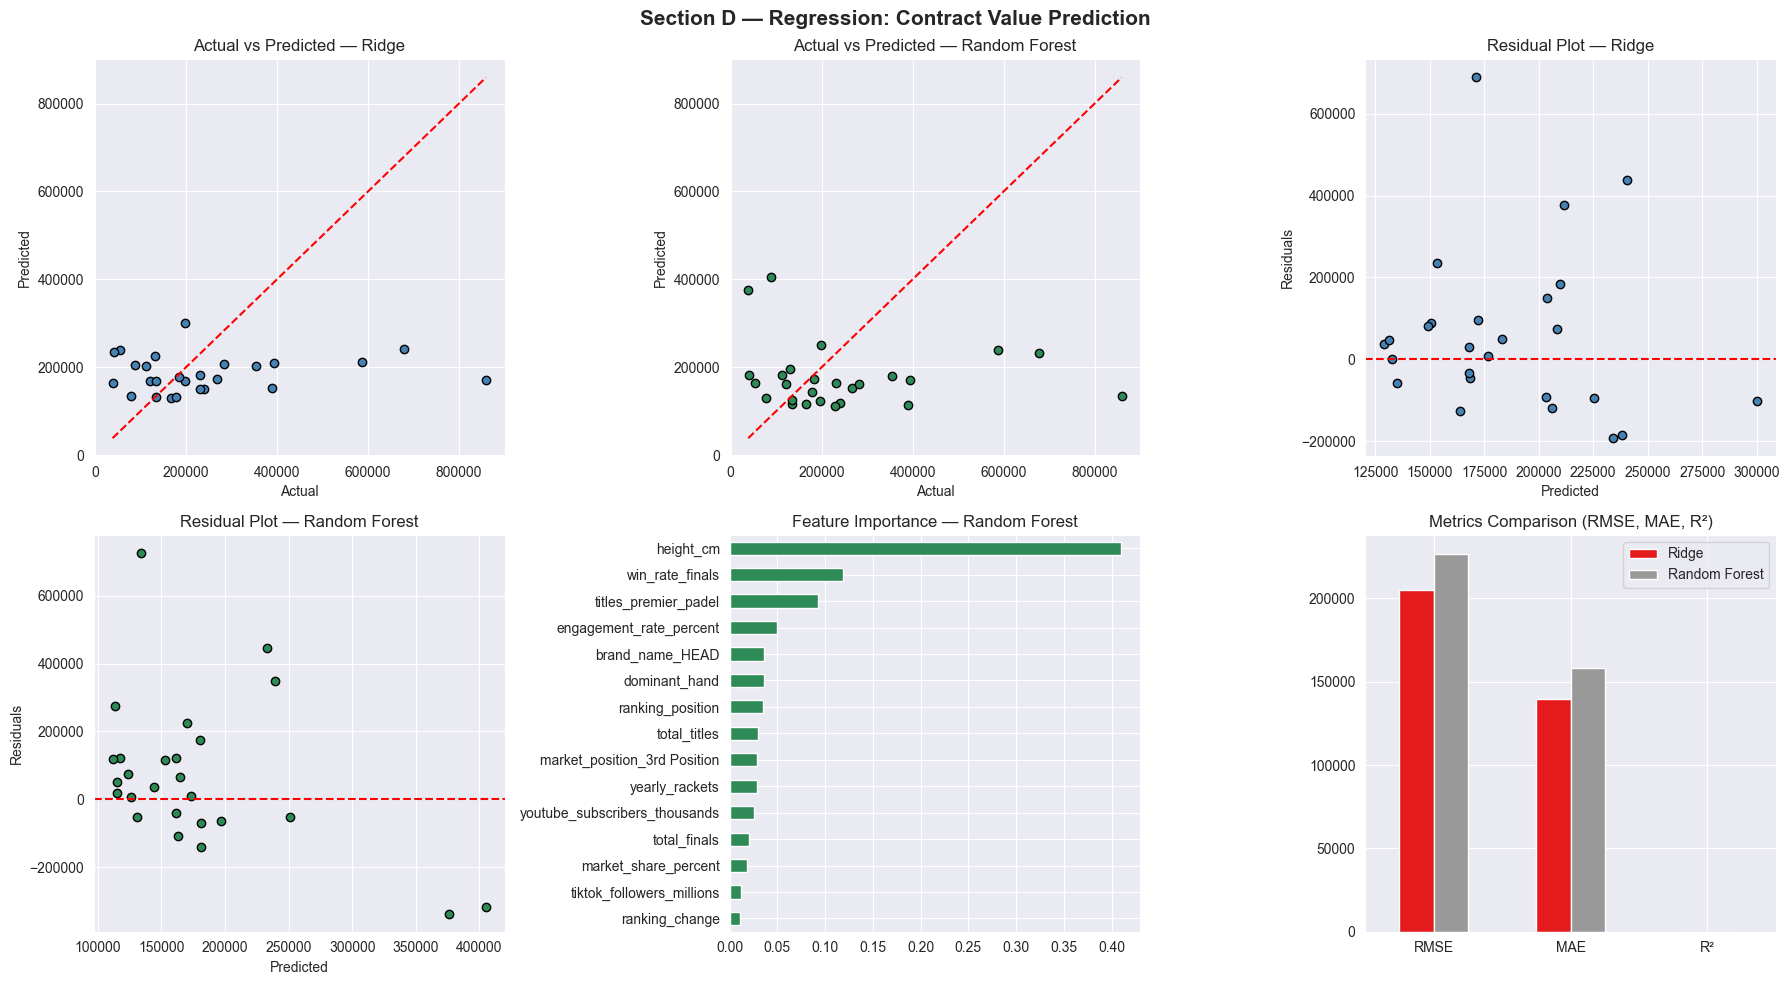


🏆 Best Regression Model: Ridge


In [3]:
# ══════════════════════════════════════════════════════════
# SECTION D — REGRESSION
# Predict: contract_value_eur (player's sponsorship contract value)
# ══════════════════════════════════════════════════════════
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
import scipy.stats as stats

# ── Prepare X and y ──
target_r = 'contract_value_eur'
drop_cols_r = [target_r, 'sponsorship_value_annual_eur',
               'is_top_player', 'performance_score']

X_r = df.drop(columns=drop_cols_r)
y_r = df[target_r]

print("Target stats:")
print(y_r.describe())

# ── Train/Test Split ──
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_r, y_r, test_size=0.2, random_state=42
)

# ── Scale ──
scaler_r = StandardScaler()
X_train_r_sc = scaler_r.fit_transform(X_train_r)
X_test_r_sc  = scaler_r.transform(X_test_r)

# ── Model 1: Ridge Regression + GridSearch ──
param_grid_ridge = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]}
ridge = GridSearchCV(Ridge(), param_grid_ridge, cv=3, scoring='r2')
ridge.fit(X_train_r_sc, y_train_r)
best_ridge = ridge.best_estimator_
y_pred_ridge = best_ridge.predict(X_test_r_sc)
print(f"\nRidge Best alpha: {ridge.best_params_}")

# ── Model 2: Random Forest Regressor + GridSearch ──
param_grid_rfr = {'n_estimators': [50, 100, 200],
                  'max_depth': [3, 5, None],
                  'min_samples_split': [2, 5]}
rfr = GridSearchCV(RandomForestRegressor(random_state=42),
                   param_grid_rfr, cv=3, scoring='r2')
rfr.fit(X_train_r, y_train_r)
best_rfr = rfr.best_estimator_
y_pred_rfr = best_rfr.predict(X_test_r)
print(f"RF Regressor Best params: {rfr.best_params_}")

# ── Metrics ──
def reg_metrics(y_true, y_pred, name):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"\n── {name} ──")
    print(f"MSE  : {mse:,.2f}")
    print(f"RMSE : {rmse:,.2f}")
    print(f"MAE  : {mae:,.2f}")
    print(f"R²   : {r2:.3f}")
    return [mse, rmse, mae, r2]

m_ridge = reg_metrics(y_test_r, y_pred_ridge, "Ridge Regression")
m_rfr   = reg_metrics(y_test_r, y_pred_rfr,   "Random Forest Regressor")

metrics_d = pd.DataFrame({
    'Ridge': m_ridge,
    'Random Forest': m_rfr
}, index=['MSE', 'RMSE', 'MAE', 'R²'])

print("\n══ REGRESSION METRICS ══")
print(metrics_d.round(3))

# ── Visualizations ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Section D — Regression: Contract Value Prediction",
             fontsize=15, fontweight='bold')

# Actual vs Predicted — Ridge
axes[0,0].scatter(y_test_r, y_pred_ridge, color='steelblue', edgecolors='k')
axes[0,0].plot([y_test_r.min(), y_test_r.max()],
               [y_test_r.min(), y_test_r.max()], 'r--')
axes[0,0].set_xlabel("Actual")
axes[0,0].set_ylabel("Predicted")
axes[0,0].set_title("Actual vs Predicted — Ridge")

# Actual vs Predicted — RF
axes[0,1].scatter(y_test_r, y_pred_rfr, color='seagreen', edgecolors='k')
axes[0,1].plot([y_test_r.min(), y_test_r.max()],
               [y_test_r.min(), y_test_r.max()], 'r--')
axes[0,1].set_xlabel("Actual")
axes[0,1].set_ylabel("Predicted")
axes[0,1].set_title("Actual vs Predicted — Random Forest")

# Residuals — Ridge
residuals_ridge = y_test_r - y_pred_ridge
axes[0,2].scatter(y_pred_ridge, residuals_ridge, color='steelblue', edgecolors='k')
axes[0,2].axhline(0, color='red', linestyle='--')
axes[0,2].set_xlabel("Predicted")
axes[0,2].set_ylabel("Residuals")
axes[0,2].set_title("Residual Plot — Ridge")

# Residuals — RF
residuals_rfr = y_test_r - y_pred_rfr
axes[1,0].scatter(y_pred_rfr, residuals_rfr, color='seagreen', edgecolors='k')
axes[1,0].axhline(0, color='red', linestyle='--')
axes[1,0].set_xlabel("Predicted")
axes[1,0].set_ylabel("Residuals")
axes[1,0].set_title("Residual Plot — Random Forest")

# Feature Importance — RF
importances_r = pd.Series(best_rfr.feature_importances_, index=X_r.columns)
importances_r.sort_values(ascending=True).tail(15).plot(
    kind='barh', ax=axes[1,1], color='seagreen')
axes[1,1].set_title("Feature Importance — Random Forest")

# Metrics Comparison
metrics_d.loc[['RMSE','MAE','R²']].plot(kind='bar', ax=axes[1,2], rot=0, colormap='Set1')
axes[1,2].set_title("Metrics Comparison (RMSE, MAE, R²)")

plt.tight_layout()
plt.show()

best_model_r = "Random Forest" if metrics_d.loc['R²','Random Forest'] >= metrics_d.loc['R²','Ridge'] else "Ridge"
print(f"\n🏆 Best Regression Model: {best_model_r}")

✅ Best K by Silhouette: 4

K-Means | Silhouette: 0.324 | Davies-Bouldin: 0.946
Hierarch | Silhouette: 0.301 | Davies-Bouldin: 0.892

PCA explained variance: 61.35%


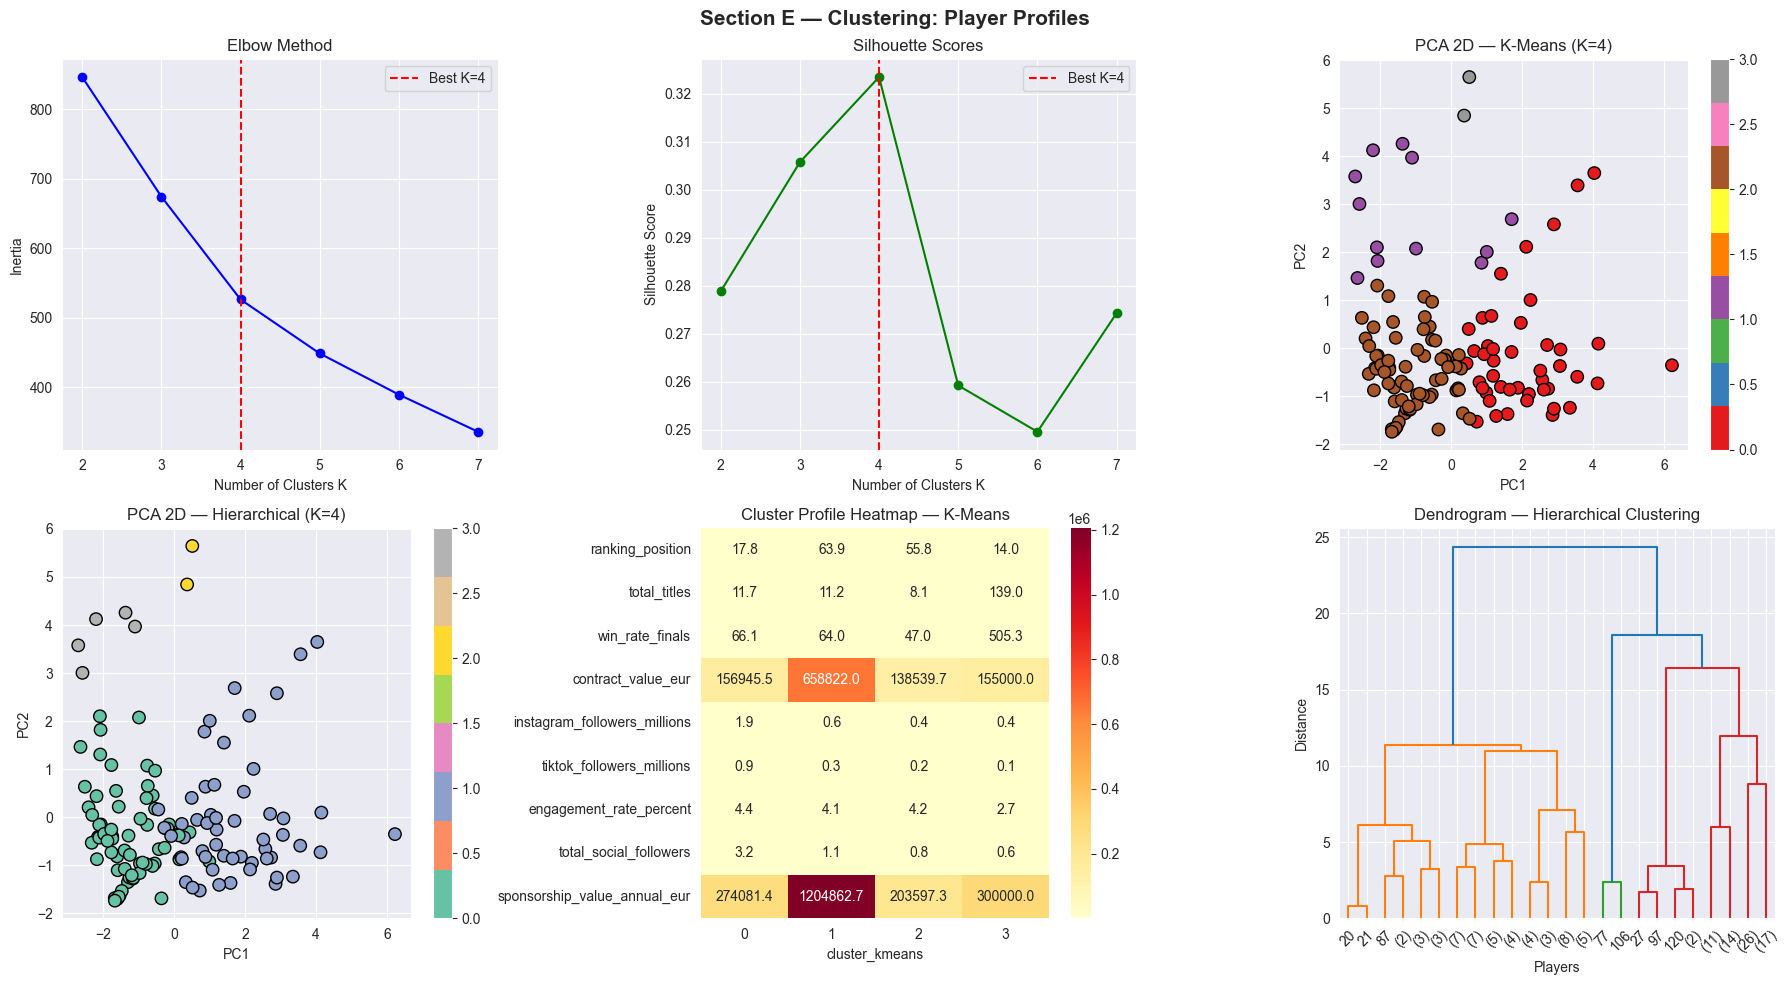


══ CLUSTERING METRICS ══
                  K-Means  Hierarchical
Silhouette ↑        0.324         0.301
Davies-Bouldin ↓    0.946         0.892

🏆 Best Clustering Model: K-Means


In [4]:
# ══════════════════════════════════════════════════════════
# SECTION E — CLUSTERING
# Group players by profile (performance + social media)
# ══════════════════════════════════════════════════════════
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

# ── Prepare features for clustering ──
cluster_features = [
    'ranking_position', 'total_titles', 'win_rate_finals',
    'contract_value_eur', 'instagram_followers_millions',
    'tiktok_followers_millions', 'engagement_rate_percent',
    'total_social_followers', 'sponsorship_value_annual_eur'
]

X_cl = df[cluster_features].copy()

# Scale
scaler_cl = StandardScaler()
X_cl_sc = scaler_cl.fit_transform(X_cl)

# ══════════════════════════════════════════════════════════
# ELBOW METHOD — Find best K
# ══════════════════════════════════════════════════════════
inertias = []
silhouettes = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cl_sc)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cl_sc, km.labels_))

best_k = k_range.start + np.argmax(silhouettes)
print(f"✅ Best K by Silhouette: {best_k}")

# ══════════════════════════════════════════════════════════
# MODEL 1 — K-MEANS
# ══════════════════════════════════════════════════════════
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans.fit_predict(X_cl_sc)

sil_km = silhouette_score(X_cl_sc, df['cluster_kmeans'])
db_km  = davies_bouldin_score(X_cl_sc, df['cluster_kmeans'])
print(f"\nK-Means | Silhouette: {sil_km:.3f} | Davies-Bouldin: {db_km:.3f}")

# ══════════════════════════════════════════════════════════
# MODEL 2 — HIERARCHICAL CLUSTERING
# ══════════════════════════════════════════════════════════
hc = AgglomerativeClustering(n_clusters=best_k)
df['cluster_hc'] = hc.fit_predict(X_cl_sc)

sil_hc = silhouette_score(X_cl_sc, df['cluster_hc'])
db_hc  = davies_bouldin_score(X_cl_sc, df['cluster_hc'])
print(f"Hierarch | Silhouette: {sil_hc:.3f} | Davies-Bouldin: {db_hc:.3f}")

# ══════════════════════════════════════════════════════════
# PCA for 2D visualization
# ══════════════════════════════════════════════════════════
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cl_sc)
print(f"\nPCA explained variance: {pca.explained_variance_ratio_.sum():.2%}")

# ══════════════════════════════════════════════════════════
# VISUALIZATIONS
# ══════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Section E — Clustering: Player Profiles",
             fontsize=15, fontweight='bold')

# Elbow curve
axes[0,0].plot(k_range, inertias, 'bo-')
axes[0,0].set_xlabel("Number of Clusters K")
axes[0,0].set_ylabel("Inertia")
axes[0,0].set_title("Elbow Method")
axes[0,0].axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
axes[0,0].legend()

# Silhouette scores
axes[0,1].plot(k_range, silhouettes, 'go-')
axes[0,1].set_xlabel("Number of Clusters K")
axes[0,1].set_ylabel("Silhouette Score")
axes[0,1].set_title("Silhouette Scores")
axes[0,1].axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
axes[0,1].legend()

# PCA 2D — K-Means
scatter1 = axes[0,2].scatter(X_pca[:, 0], X_pca[:, 1],
                              c=df['cluster_kmeans'], cmap='Set1', s=80, edgecolors='k')
axes[0,2].set_title(f"PCA 2D — K-Means (K={best_k})")
axes[0,2].set_xlabel("PC1")
axes[0,2].set_ylabel("PC2")
plt.colorbar(scatter1, ax=axes[0,2])

# PCA 2D — Hierarchical
scatter2 = axes[1,0].scatter(X_pca[:, 0], X_pca[:, 1],
                              c=df['cluster_hc'], cmap='Set2', s=80, edgecolors='k')
axes[1,0].set_title(f"PCA 2D — Hierarchical (K={best_k})")
axes[1,0].set_xlabel("PC1")
axes[1,0].set_ylabel("PC2")
plt.colorbar(scatter2, ax=axes[1,0])

# Cluster profiles heatmap — K-Means
cluster_profile = df.groupby('cluster_kmeans')[cluster_features].mean()
sns.heatmap(cluster_profile.T, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[1,1])
axes[1,1].set_title("Cluster Profile Heatmap — K-Means")

# Dendrogram
linked = linkage(X_cl_sc, method='ward')
dendrogram(linked, ax=axes[1,2], truncate_mode='level', p=4,
           color_threshold=0.7*max(linked[:,2]))
axes[1,2].set_title("Dendrogram — Hierarchical Clustering")
axes[1,2].set_xlabel("Players")
axes[1,2].set_ylabel("Distance")

plt.tight_layout()
plt.show()

# ── Metrics Summary ──
print("\n══ CLUSTERING METRICS ══")
metrics_e = pd.DataFrame({
    'K-Means':       [sil_km, db_km],
    'Hierarchical':  [sil_hc, db_hc]
}, index=['Silhouette ↑', 'Davies-Bouldin ↓'])
print(metrics_e.round(3))

best_model_e = "K-Means" if sil_km >= sil_hc else "Hierarchical"
print(f"\n🏆 Best Clustering Model: {best_model_e}")


── METHOD 1: Filter (SelectKBest) — Top 10 ──
                      Feature     Score
youtube_subscribers_thousands 37.796634
 instagram_followers_millions 32.958900
  twitter_followers_thousands 31.501840
       total_social_followers 29.359926
    tiktok_followers_millions 15.382310
      titles_world_padel_tour 10.901904
                 total_titles 10.870510
              win_rate_finals  9.577938
             sponsorship_type  5.435782
                 total_finals  3.325957

── METHOD 2: Wrapper (RFE) — Top 10 ──
['total_titles', 'titles_premier_padel', 'titles_world_padel_tour', 'total_finals', 'instagram_followers_millions', 'tiktok_followers_millions', 'youtube_subscribers_thousands', 'engagement_rate_percent', 'brand_name_Babolat', 'total_social_followers']

── METHOD 3: Embedded (Random Forest) — Top 10 ──
total_social_followers           0.1104
twitter_followers_thousands      0.0965
youtube_subscribers_thousands    0.0904
instagram_followers_millions     0.0740
tiktok_fol

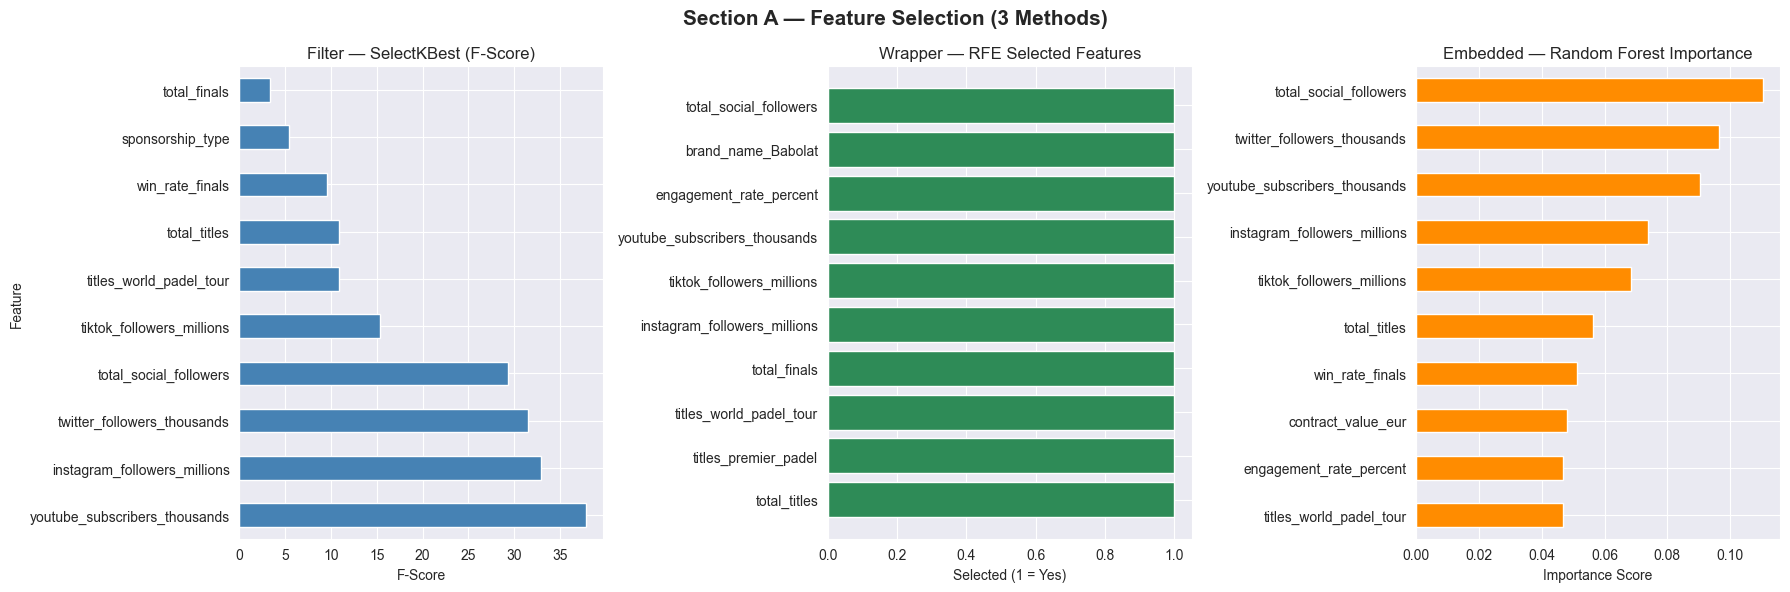


✅ Features selected by ALL 3 methods (6):
   → total_social_followers
   → total_titles
   → youtube_subscribers_thousands
   → tiktok_followers_millions
   → instagram_followers_millions
   → titles_world_padel_tour


In [5]:
# ══════════════════════════════════════════════════════════
# SECTION A (COMPLEMENT) — FEATURE SELECTION
# 3 Methods: Filter, Wrapper, Embedded
# ══════════════════════════════════════════════════════════
from sklearn.feature_selection import SelectKBest, f_classif, RFE

target_fs = 'is_top_player'
drop_cols_fs = ['is_top_player', 'ranking_position',
                'ranking_points', 'performance_score',
                'cluster_kmeans', 'cluster_hc']

X_fs = df.drop(columns=drop_cols_fs)
y_fs = df[target_fs]

scaler_fs = StandardScaler()
X_fs_sc = scaler_fs.fit_transform(X_fs)

# ══════════════════════════════════════════════════════════
# METHOD 1 — FILTER (SelectKBest)
# ══════════════════════════════════════════════════════════
selector_filter = SelectKBest(f_classif, k=10)
selector_filter.fit(X_fs_sc, y_fs)
filter_features = X_fs.columns[selector_filter.get_support()]
filter_scores   = selector_filter.scores_[selector_filter.get_support()]
filter_df = pd.DataFrame({
    'Feature': filter_features,
    'Score': filter_scores
}).sort_values('Score', ascending=False)

print("── METHOD 1: Filter (SelectKBest) — Top 10 ──")
print(filter_df.to_string(index=False))

# ══════════════════════════════════════════════════════════
# METHOD 2 — WRAPPER (RFE)
# ══════════════════════════════════════════════════════════
rfe = RFE(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    n_features_to_select=10
)
rfe.fit(X_fs_sc, y_fs)
wrapper_features = X_fs.columns[rfe.support_]

print("\n── METHOD 2: Wrapper (RFE) — Top 10 ──")
print(list(wrapper_features))

# ══════════════════════════════════════════════════════════
# METHOD 3 — EMBEDDED (Random Forest Importance)
# ══════════════════════════════════════════════════════════
rf_fs = RandomForestClassifier(n_estimators=100, random_state=42)
rf_fs.fit(X_fs_sc, y_fs)
importances_fs = pd.Series(rf_fs.feature_importances_, index=X_fs.columns)
embedded_features = importances_fs.sort_values(ascending=False).head(10)

print("\n── METHOD 3: Embedded (Random Forest) — Top 10 ──")
print(embedded_features.round(4).to_string())

# ══════════════════════════════════════════════════════════
# VISUALIZATIONS
# ══════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Section A — Feature Selection (3 Methods)",
             fontsize=15, fontweight='bold')

# Filter
filter_df.plot(kind='barh', x='Feature', y='Score',
               ax=axes[0], color='steelblue', legend=False)
axes[0].set_title("Filter — SelectKBest (F-Score)")
axes[0].set_xlabel("F-Score")

# Wrapper
axes[1].barh(wrapper_features, [1]*len(wrapper_features), color='seagreen')
axes[1].set_title("Wrapper — RFE Selected Features")
axes[1].set_xlabel("Selected (1 = Yes)")

# Embedded
embedded_features.sort_values().plot(
    kind='barh', ax=axes[2], color='darkorange')
axes[2].set_title("Embedded — Random Forest Importance")
axes[2].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

# ── Common features across all 3 methods ──
common = set(filter_features) & set(wrapper_features) & set(embedded_features.index)
print(f"\n✅ Features selected by ALL 3 methods ({len(common)}):")
for f in common:
    print(f"   → {f}")

── Class Distribution BEFORE SMOTE ──
is_top_player
0    88
1    41
Name: count, dtype: int64
Balance ratio: 31.78% positive

── Class Distribution AFTER SMOTE ──
is_top_player
0    88
1    88
Name: count, dtype: int64
Balance ratio: 50.00% positive

── K-Fold Cross Validation — Classification ──

Logistic Regression (5-Fold):
  Accuracy : 0.785 ± 0.069
  F1-Score : 0.786  ± 0.059
  ROC-AUC  : 0.845 ± 0.046

Random Forest (5-Fold):
  Accuracy : 0.824 ± 0.034
  F1-Score : 0.826  ± 0.038
  ROC-AUC  : 0.899 ± 0.031

── K-Fold Cross Validation — Regression ──

Ridge Regression (5-Fold):
  R²   : -0.295   ± 0.293
  RMSE : 178,092 ± 58,769

Random Forest Regressor (5-Fold):
  R²   : -0.382   ± 0.508
  RMSE : 179,233 ± 56,996


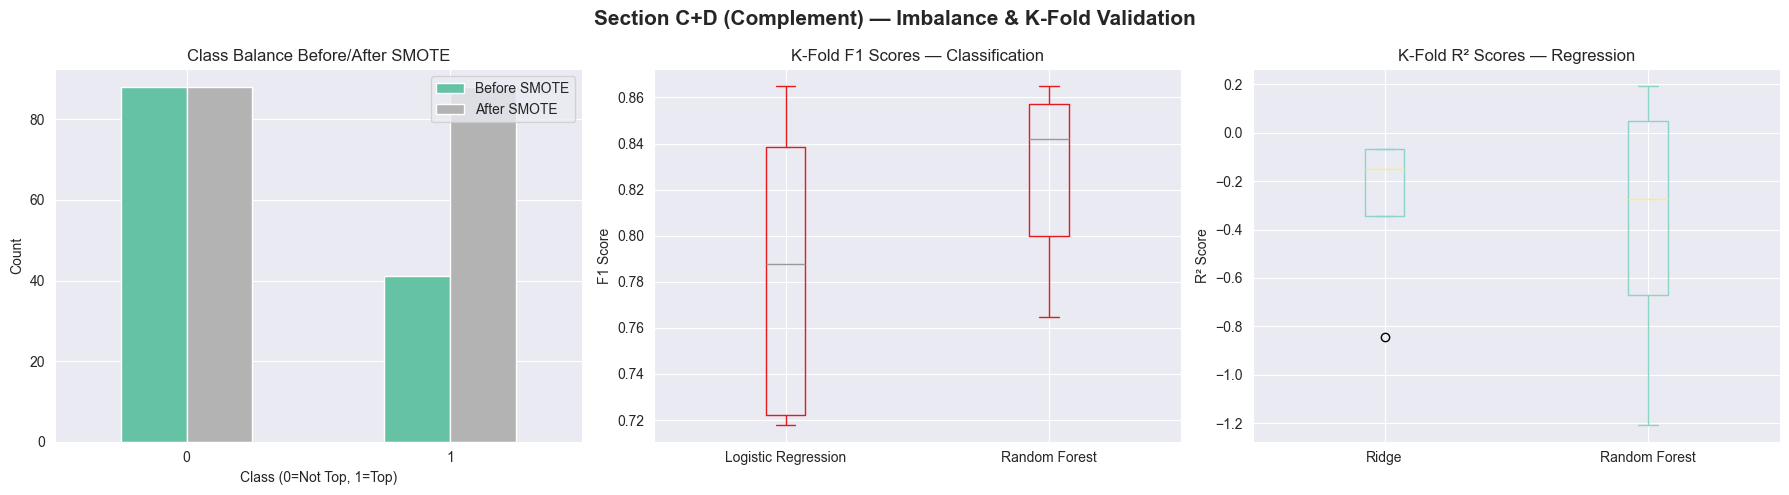


✅ Imbalance handling and K-Fold validation complete!


In [6]:
# ══════════════════════════════════════════════════════════
# SECTION C (COMPLEMENT) — IMBALANCE HANDLING + K-FOLD
# ══════════════════════════════════════════════════════════
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import KFold, StratifiedKFold

target_im = 'is_top_player'
drop_cols_im = ['is_top_player', 'ranking_position',
                'ranking_points', 'performance_score',
                'cluster_kmeans', 'cluster_hc']

X_im = df.drop(columns=drop_cols_im)
y_im = df[target_im]

print("── Class Distribution BEFORE SMOTE ──")
print(y_im.value_counts())
print(f"Balance ratio: {y_im.mean():.2%} positive")

# ══════════════════════════════════════════════════════════
# SMOTE — Synthetic Minority Oversampling
# ══════════════════════════════════════════════════════════
smote = SMOTE(random_state=42, k_neighbors=3)
X_bal, y_bal = smote.fit_resample(X_im, y_im)

print("\n── Class Distribution AFTER SMOTE ──")
print(pd.Series(y_bal).value_counts())
print(f"Balance ratio: {pd.Series(y_bal).mean():.2%} positive")

# ══════════════════════════════════════════════════════════
# K-FOLD CROSS VALIDATION — Classification
# ══════════════════════════════════════════════════════════
print("\n── K-Fold Cross Validation — Classification ──")

scaler_im = StandardScaler()
X_bal_sc = scaler_im.fit_transform(X_bal)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression K-Fold
lr_kf = LogisticRegression(max_iter=1000, random_state=42, **lr.best_params_)
cv_lr_acc = cross_val_score(lr_kf, X_bal_sc, y_bal, cv=skf, scoring='accuracy')
cv_lr_f1  = cross_val_score(lr_kf, X_bal_sc, y_bal, cv=skf, scoring='f1')
cv_lr_auc = cross_val_score(lr_kf, X_bal_sc, y_bal, cv=skf, scoring='roc_auc')

print(f"\nLogistic Regression (5-Fold):")
print(f"  Accuracy : {cv_lr_acc.mean():.3f} ± {cv_lr_acc.std():.3f}")
print(f"  F1-Score : {cv_lr_f1.mean():.3f}  ± {cv_lr_f1.std():.3f}")
print(f"  ROC-AUC  : {cv_lr_auc.mean():.3f} ± {cv_lr_auc.std():.3f}")

# Random Forest K-Fold
rf_kf = RandomForestClassifier(random_state=42, **rf.best_params_)
cv_rf_acc = cross_val_score(rf_kf, X_bal, y_bal, cv=skf, scoring='accuracy')
cv_rf_f1  = cross_val_score(rf_kf, X_bal, y_bal, cv=skf, scoring='f1')
cv_rf_auc = cross_val_score(rf_kf, X_bal, y_bal, cv=skf, scoring='roc_auc')

print(f"\nRandom Forest (5-Fold):")
print(f"  Accuracy : {cv_rf_acc.mean():.3f} ± {cv_rf_acc.std():.3f}")
print(f"  F1-Score : {cv_rf_f1.mean():.3f}  ± {cv_rf_f1.std():.3f}")
print(f"  ROC-AUC  : {cv_rf_auc.mean():.3f} ± {cv_rf_auc.std():.3f}")

# ══════════════════════════════════════════════════════════
# K-FOLD CROSS VALIDATION — Regression
# ══════════════════════════════════════════════════════════
print("\n── K-Fold Cross Validation — Regression ──")

kf_r = KFold(n_splits=5, shuffle=True, random_state=42)

# Ridge K-Fold
cv_ridge_r2   = cross_val_score(best_ridge, X_train_r_sc, y_train_r, cv=kf_r, scoring='r2')
cv_ridge_rmse = cross_val_score(best_ridge, X_train_r_sc, y_train_r, cv=kf_r,
                                scoring='neg_root_mean_squared_error')
print(f"\nRidge Regression (5-Fold):")
print(f"  R²   : {cv_ridge_r2.mean():.3f}   ± {cv_ridge_r2.std():.3f}")
print(f"  RMSE : {(-cv_ridge_rmse).mean():,.0f} ± {(-cv_ridge_rmse).std():,.0f}")

# Random Forest Regressor K-Fold
cv_rfr_r2   = cross_val_score(best_rfr, X_train_r, y_train_r, cv=kf_r, scoring='r2')
cv_rfr_rmse = cross_val_score(best_rfr, X_train_r, y_train_r, cv=kf_r,
                              scoring='neg_root_mean_squared_error')
print(f"\nRandom Forest Regressor (5-Fold):")
print(f"  R²   : {cv_rfr_r2.mean():.3f}   ± {cv_rfr_r2.std():.3f}")
print(f"  RMSE : {(-cv_rfr_rmse).mean():,.0f} ± {(-cv_rfr_rmse).std():,.0f}")

# ══════════════════════════════════════════════════════════
# VISUALIZATIONS
# ══════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Section C+D (Complement) — Imbalance & K-Fold Validation",
             fontsize=15, fontweight='bold')

# Class balance before/after SMOTE
balance_data = pd.DataFrame({
    'Before SMOTE': y_im.value_counts().sort_index(),
    'After SMOTE' : pd.Series(y_bal).value_counts().sort_index()
})
balance_data.plot(kind='bar', ax=axes[0], colormap='Set2', rot=0)
axes[0].set_title("Class Balance Before/After SMOTE")
axes[0].set_xlabel("Class (0=Not Top, 1=Top)")
axes[0].set_ylabel("Count")

# K-Fold Classification F1
kfold_clf = pd.DataFrame({
    'Logistic Regression': cv_lr_f1,
    'Random Forest'      : cv_rf_f1
})
kfold_clf.plot(kind='box', ax=axes[1], colormap='Set1')
axes[1].set_title("K-Fold F1 Scores — Classification")
axes[1].set_ylabel("F1 Score")

# K-Fold Regression R²
kfold_reg = pd.DataFrame({
    'Ridge'        : cv_ridge_r2,
    'Random Forest': cv_rfr_r2
})
kfold_reg.plot(kind='box', ax=axes[2], colormap='Set3')
axes[2].set_title("K-Fold R² Scores — Regression")
axes[2].set_ylabel("R² Score")

plt.tight_layout()
plt.show()

print("\n✅ Imbalance handling and K-Fold validation complete!")

✅ Time Series Data loaded: (129, 16)
Date range: 2022-02-08 00:00:00 → 2026-11-30 00:00:00
Players: 110

✅ Monthly aggregated: 48 periods
  year_month  avg_ranking  avg_contract  avg_instagram  avg_engagement  \
0    2022-02        60.50     136614.75         0.3850            6.15   
1    2022-03        56.75     151514.25         0.6125            5.10   
2    2022-04        54.00     156716.00         0.5350            6.50   
3    2022-05        51.00     126176.50         1.6100            4.95   
4    2022-06        84.00      18943.00         0.2400            7.30   

   player_count year_month_dt  
0             4    2022-02-01  
1             4    2022-03-01  
2             2    2022-04-01  
3             2    2022-05-01  
4             1    2022-06-01  

── ADF Test ──
ADF Statistic : -2.0238
p-value       : 0.2762
Stationary    : ❌ No — needs differencing

── KPSS Test ──
KPSS Statistic: 0.0941
p-value       : 0.1000
Stationary    : ✅ Yes


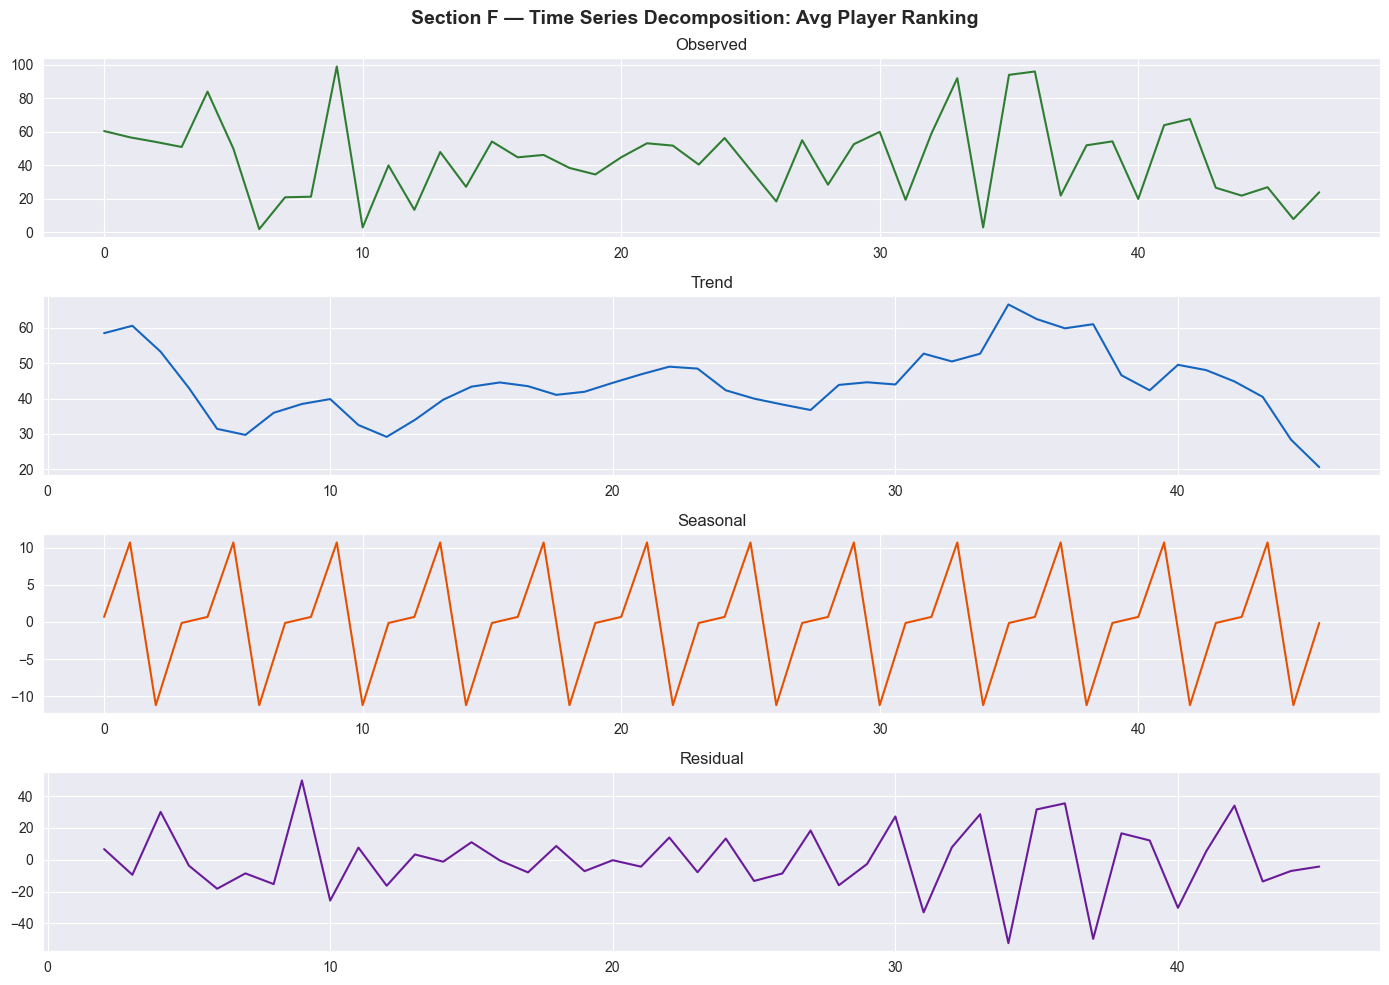

✅ Decomposition done

Train: 38 periods | Test: 10 periods

── Model 1: ARIMA ──
MAE  : 20.261
RMSE : 22.689
MAPE : 107.38%

── Model 2: Gradient Boosting (XGBoost-style TS) ──
MAE  : 21.336
RMSE : 24.922
MAPE : 116.39%


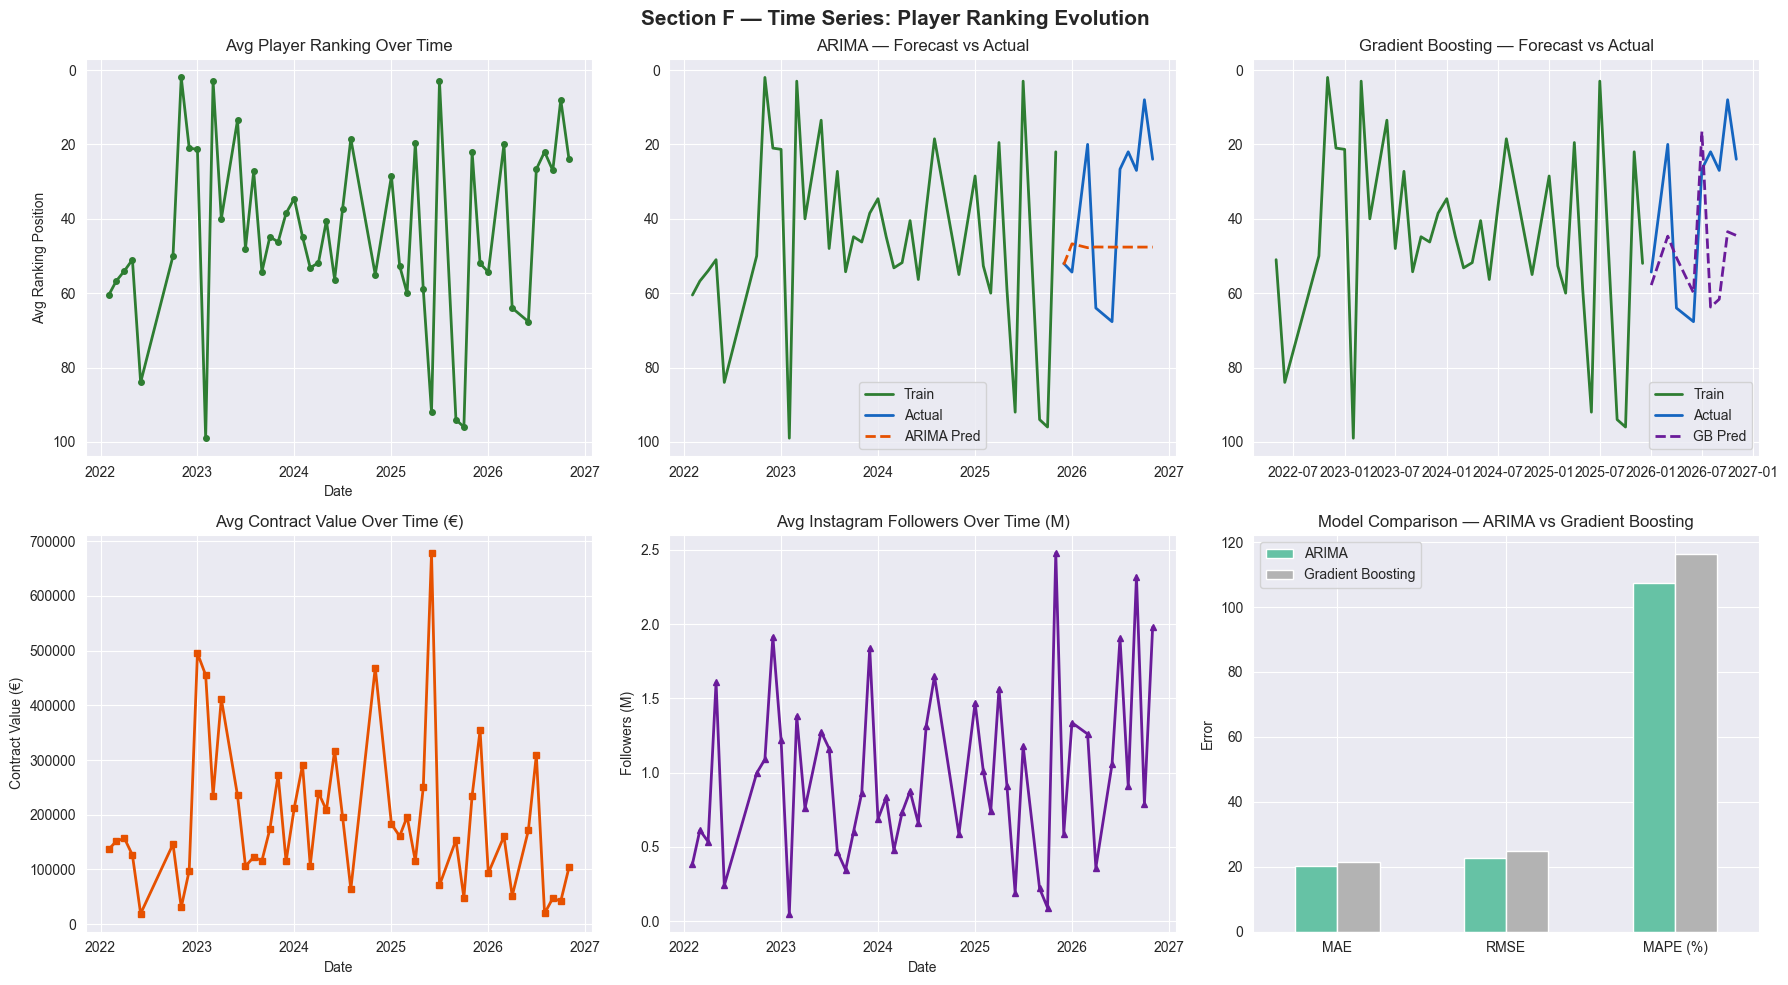


══ TIME SERIES METRICS ══
            ARIMA  Gradient Boosting
MAE        20.261             21.336
RMSE       22.689             24.922
MAPE (%)  107.381            116.395

🏆 Best Time Series Model: ARIMA

── Future Forecast: Next 6 months ──


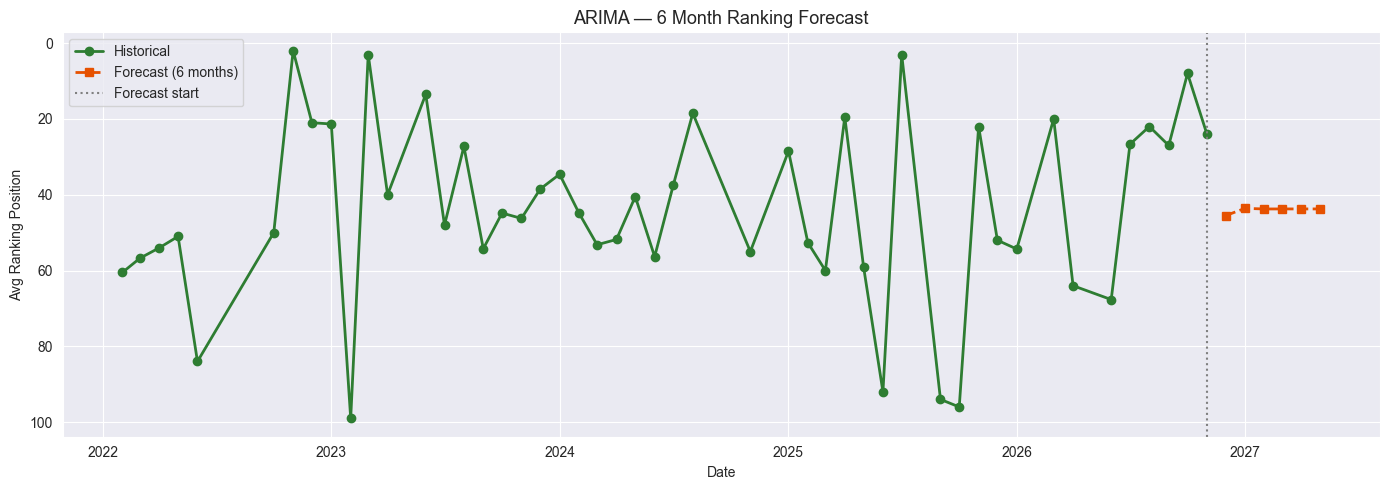

Future ranking predictions:
  2026-12 → Avg Ranking: 45.5
  2027-01 → Avg Ranking: 43.6
  2027-02 → Avg Ranking: 43.8
  2027-03 → Avg Ranking: 43.7
  2027-04 → Avg Ranking: 43.7
  2027-05 → Avg Ranking: 43.7


In [7]:
# ══════════════════════════════════════════════════════════
# SECTION F — TIME SERIES
# Predict player ranking_position evolution over time
# ══════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════
# 1. LOAD & PREPARE
# ══════════════════════════════════════════════════════════
df_ts = pd.read_csv("player_timeseries.csv")
df_ts['full_date'] = pd.to_datetime(df_ts['full_date'])
df_ts = df_ts.sort_values('full_date')

print("✅ Time Series Data loaded:", df_ts.shape)
print(f"Date range: {df_ts['full_date'].min()} → {df_ts['full_date'].max()}")
print(f"Players: {df_ts['player_name'].nunique()}")

# ══════════════════════════════════════════════════════════
# 2. AGGREGATE — Monthly average ranking
# ══════════════════════════════════════════════════════════
df_ts['year_month'] = df_ts['full_date'].dt.to_period('M')

monthly = df_ts.groupby('year_month').agg(
    avg_ranking     = ('ranking_position', 'mean'),
    avg_contract    = ('contract_value_eur', 'mean'),
    avg_instagram   = ('instagram_followers_millions', 'mean'),
    avg_engagement  = ('engagement_rate_percent', 'mean'),
    player_count    = ('player_name', 'count')
).reset_index()

monthly['year_month_dt'] = monthly['year_month'].dt.to_timestamp()
monthly = monthly.sort_values('year_month_dt')

print(f"\n✅ Monthly aggregated: {monthly.shape[0]} periods")
print(monthly.head())

# ══════════════════════════════════════════════════════════
# 3. STATIONARITY TESTS
# ══════════════════════════════════════════════════════════
series = monthly['avg_ranking'].dropna()

# ADF Test
adf_result = adfuller(series)
print(f"\n── ADF Test ──")
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Stationary    : {'✅ Yes' if adf_result[1] < 0.05 else '❌ No — needs differencing'}")

# KPSS Test
kpss_result = kpss(series, regression='c')
print(f"\n── KPSS Test ──")
print(f"KPSS Statistic: {kpss_result[0]:.4f}")
print(f"p-value       : {kpss_result[1]:.4f}")
print(f"Stationary    : {'✅ Yes' if kpss_result[1] > 0.05 else '❌ No'}")

# ══════════════════════════════════════════════════════════
# 4. DECOMPOSITION
# ══════════════════════════════════════════════════════════
if len(series) >= 12:
    decomposition = seasonal_decompose(series, model='additive', period=4)
    fig, axes = plt.subplots(4, 1, figsize=(14, 10))
    fig.suptitle("Section F — Time Series Decomposition: Avg Player Ranking",
                 fontsize=14, fontweight='bold')
    decomposition.observed.plot(ax=axes[0], color='#2e7d32')
    axes[0].set_title("Observed")
    decomposition.trend.plot(ax=axes[1], color='#1565c0')
    axes[1].set_title("Trend")
    decomposition.seasonal.plot(ax=axes[2], color='#e65100')
    axes[2].set_title("Seasonal")
    decomposition.resid.plot(ax=axes[3], color='#6a1b9a')
    axes[3].set_title("Residual")
    plt.tight_layout()
    plt.show()
    print("✅ Decomposition done")
else:
    print("⚠️ Not enough data for decomposition — skipping")

# ══════════════════════════════════════════════════════════
# 5. TRAIN/TEST SPLIT (80/20)
# ══════════════════════════════════════════════════════════
split = int(len(monthly) * 0.8)
train = monthly[:split]
test  = monthly[split:]

print(f"\nTrain: {len(train)} periods | Test: {len(test)} periods")

# ══════════════════════════════════════════════════════════
# 6. MODEL 1 — ARIMA
# ══════════════════════════════════════════════════════════
print("\n── Model 1: ARIMA ──")
try:
    arima = ARIMA(train['avg_ranking'], order=(1,1,1))
    arima_fit = arima.fit()
    arima_pred = arima_fit.forecast(steps=len(test))
    arima_pred = np.array(arima_pred)

    mae_arima  = mean_absolute_error(test['avg_ranking'], arima_pred)
    rmse_arima = np.sqrt(mean_squared_error(test['avg_ranking'], arima_pred))
    mape_arima = np.mean(np.abs((test['avg_ranking'].values - arima_pred) /
                                 test['avg_ranking'].values)) * 100

    print(f"MAE  : {mae_arima:.3f}")
    print(f"RMSE : {rmse_arima:.3f}")
    print(f"MAPE : {mape_arima:.2f}%")
except Exception as e:
    print(f"ARIMA error: {e}")
    arima_pred = np.full(len(test), train['avg_ranking'].mean())
    mae_arima  = mean_absolute_error(test['avg_ranking'], arima_pred)
    rmse_arima = np.sqrt(mean_squared_error(test['avg_ranking'], arima_pred))
    mape_arima = 0

# ══════════════════════════════════════════════════════════
# 7. MODEL 2 — XGBoost Time Series
# ══════════════════════════════════════════════════════════
print("\n── Model 2: Gradient Boosting (XGBoost-style TS) ──")

def create_features(df):
    df = df.copy()
    df['month']        = df['year_month_dt'].dt.month
    df['quarter']      = df['year_month_dt'].dt.quarter
    df['year']         = df['year_month_dt'].dt.year
    df['lag_1']        = df['avg_ranking'].shift(1)
    df['lag_2']        = df['avg_ranking'].shift(2)
    df['lag_3']        = df['avg_ranking'].shift(3)
    df['rolling_mean'] = df['avg_ranking'].shift(1).rolling(3).mean()
    return df.dropna()

monthly_feat = create_features(monthly)
split_feat   = int(len(monthly_feat) * 0.8)
train_feat   = monthly_feat[:split_feat]
test_feat    = monthly_feat[split_feat:]

features = ['month', 'quarter', 'year', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean']

if len(train_feat) > 3 and len(test_feat) > 0:
    gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
    gb.fit(train_feat[features], train_feat['avg_ranking'])
    gb_pred = gb.predict(test_feat[features])

    mae_gb  = mean_absolute_error(test_feat['avg_ranking'], gb_pred)
    rmse_gb = np.sqrt(mean_squared_error(test_feat['avg_ranking'], gb_pred))
    mape_gb = np.mean(np.abs((test_feat['avg_ranking'].values - gb_pred) /
                              test_feat['avg_ranking'].values)) * 100

    print(f"MAE  : {mae_gb:.3f}")
    print(f"RMSE : {rmse_gb:.3f}")
    print(f"MAPE : {mape_gb:.2f}%")
else:
    print("⚠️ Not enough data for GB model")
    gb_pred = np.full(len(test_feat), train_feat['avg_ranking'].mean())
    mae_gb = rmse_gb = mape_gb = 0

# ══════════════════════════════════════════════════════════
# 8. VISUALIZATIONS
# ══════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Section F — Time Series: Player Ranking Evolution",
             fontsize=15, fontweight='bold')

# Full time series
axes[0,0].plot(monthly['year_month_dt'], monthly['avg_ranking'],
               color='#2e7d32', linewidth=2, marker='o', markersize=4)
axes[0,0].set_title("Avg Player Ranking Over Time")
axes[0,0].set_xlabel("Date")
axes[0,0].set_ylabel("Avg Ranking Position")
axes[0,0].invert_yaxis()

# ARIMA predictions
axes[0,1].plot(train['year_month_dt'], train['avg_ranking'],
               label='Train', color='#2e7d32', linewidth=2)
axes[0,1].plot(test['year_month_dt'], test['avg_ranking'],
               label='Actual', color='#1565c0', linewidth=2)
axes[0,1].plot(test['year_month_dt'], arima_pred,
               label='ARIMA Pred', color='#e65100',
               linewidth=2, linestyle='--')
axes[0,1].set_title("ARIMA — Forecast vs Actual")
axes[0,1].legend()
axes[0,1].invert_yaxis()

# GB predictions
if len(test_feat) > 0:
    axes[0,2].plot(train_feat['year_month_dt'], train_feat['avg_ranking'],
                   label='Train', color='#2e7d32', linewidth=2)
    axes[0,2].plot(test_feat['year_month_dt'], test_feat['avg_ranking'],
                   label='Actual', color='#1565c0', linewidth=2)
    axes[0,2].plot(test_feat['year_month_dt'], gb_pred,
                   label='GB Pred', color='#6a1b9a',
                   linewidth=2, linestyle='--')
    axes[0,2].set_title("Gradient Boosting — Forecast vs Actual")
    axes[0,2].legend()
    axes[0,2].invert_yaxis()

# Contract value over time
axes[1,0].plot(monthly['year_month_dt'], monthly['avg_contract'],
               color='#e65100', linewidth=2, marker='s', markersize=4)
axes[1,0].set_title("Avg Contract Value Over Time (€)")
axes[1,0].set_xlabel("Date")
axes[1,0].set_ylabel("Contract Value (€)")

# Instagram followers over time
axes[1,1].plot(monthly['year_month_dt'], monthly['avg_instagram'],
               color='#6a1b9a', linewidth=2, marker='^', markersize=4)
axes[1,1].set_title("Avg Instagram Followers Over Time (M)")
axes[1,1].set_xlabel("Date")
axes[1,1].set_ylabel("Followers (M)")

# Metrics comparison
metrics_f = pd.DataFrame({
    'ARIMA'            : [mae_arima, rmse_arima, mape_arima],
    'Gradient Boosting': [mae_gb,    rmse_gb,    mape_gb]
}, index=['MAE', 'RMSE', 'MAPE (%)'])

metrics_f.plot(kind='bar', ax=axes[1,2], rot=0, colormap='Set2')
axes[1,2].set_title("Model Comparison — ARIMA vs Gradient Boosting")
axes[1,2].set_ylabel("Error")

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════
# 9. FINAL COMPARISON
# ══════════════════════════════════════════════════════════
print("\n══ TIME SERIES METRICS ══")
print(metrics_f.round(3))

best_ts = "ARIMA" if mae_arima <= mae_gb else "Gradient Boosting"
print(f"\n🏆 Best Time Series Model: {best_ts}")

# ══════════════════════════════════════════════════════════
# 10. FUTURE FORECAST (next 6 months)
# ══════════════════════════════════════════════════════════
print("\n── Future Forecast: Next 6 months ──")
try:
    arima_future = ARIMA(monthly['avg_ranking'], order=(1,1,1))
    arima_future_fit = arima_future.fit()
    future_pred = arima_future_fit.forecast(steps=6)

    future_dates = pd.date_range(
        start=monthly['year_month_dt'].max(),
        periods=7, freq='MS'
    )[1:]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(monthly['year_month_dt'], monthly['avg_ranking'],
            color='#2e7d32', linewidth=2, label='Historical', marker='o')
    ax.plot(future_dates, future_pred,
            color='#e65100', linewidth=2, linestyle='--',
            label='Forecast (6 months)', marker='s')
    ax.axvline(monthly['year_month_dt'].max(),
               color='gray', linestyle=':', label='Forecast start')
    ax.set_title("ARIMA — 6 Month Ranking Forecast", fontsize=13)
    ax.set_xlabel("Date")
    ax.set_ylabel("Avg Ranking Position")
    ax.legend()
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

    print("Future ranking predictions:")
    for date, pred in zip(future_dates, future_pred):
        print(f"  {date.strftime('%Y-%m')} → Avg Ranking: {pred:.1f}")
except Exception as e:
    print(f"Future forecast error: {e}")